In [1]:
import numpy as np
import sep

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

Replaced fitsio.read

In [3]:
with fits.open("jw02731-o001_t017_nircam_clear-f090w_i2d.fits") as hdul:
    data = hdul[1].data.astype(hdul[1].data.dtype.newbyteorder('='))

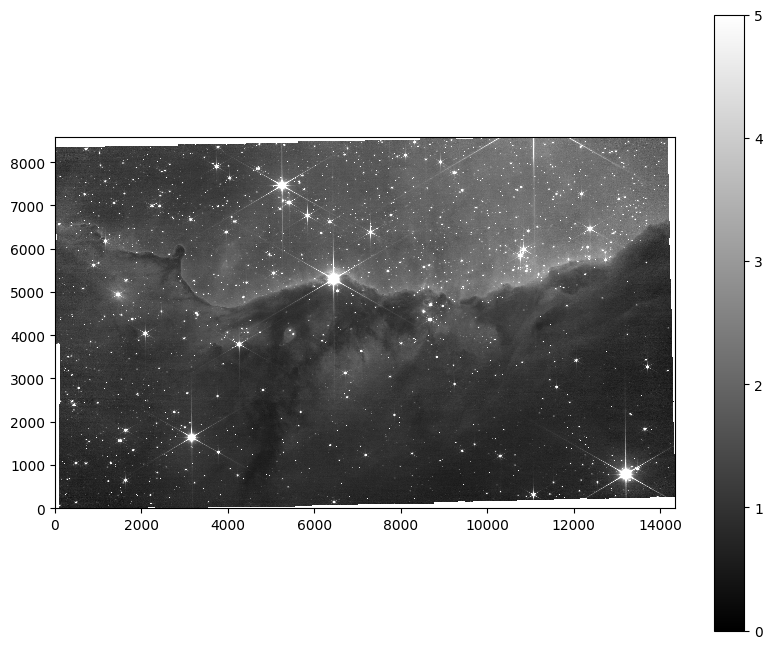

In [4]:
# show the image
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=0, vmax=5, origin='lower')
plt.colorbar();
plt.savefig("nircam_img1.png")

In [5]:
# measure a spatially varying background on the image
bkg = sep.Background(data)

In [6]:
bkg = sep.Background(data, bw=64, bh=64, fw=3, fh=3)

In [7]:
# get a "global" mean and noise of the image background:
print(bkg.globalback)
print(bkg.globalrms)

1.1956995725631714
0.06582547724246979


In [8]:
# evaluate background as 2-d array, same size as original image
bkg_image = bkg.back()
# bkg_image = np.array(bkg) # equivalent to above

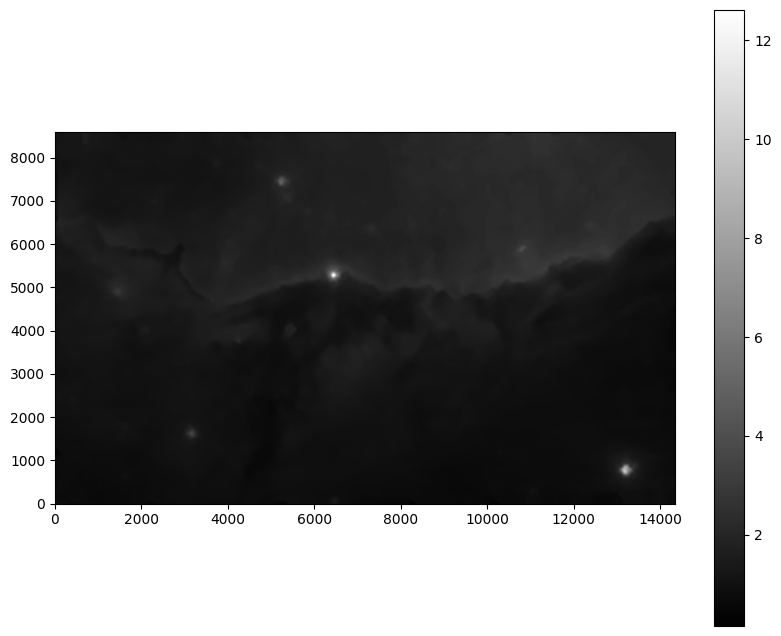

In [9]:
# show the background
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();
plt.savefig("nircam_img2.png")

In [10]:
# evaluate the background noise as 2-d array, same size as original image
bkg_rms = bkg.rms()

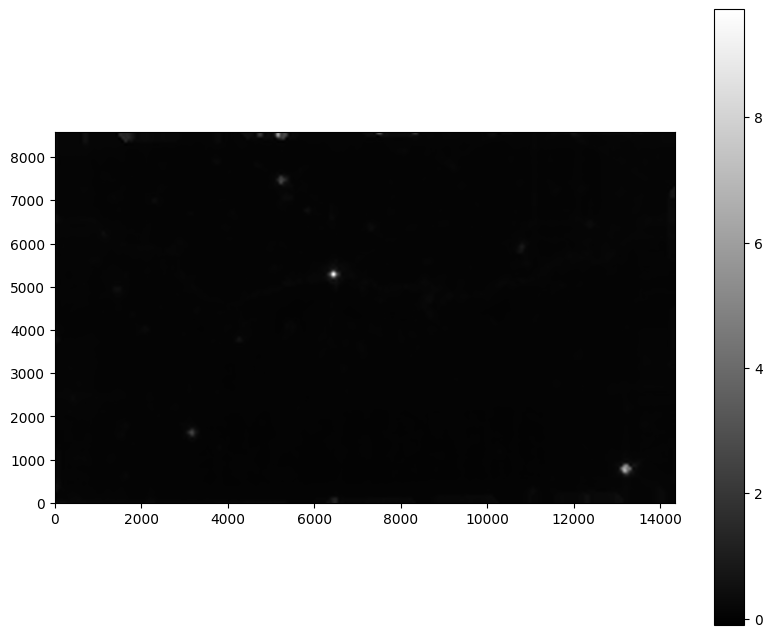

In [11]:
# show the background noise
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();
plt.savefig("nircam_img3.png")

In [12]:
# subtract the background
data_sub = data - bkg

In [13]:
objects = sep.extract(data_sub, 10.0, err=bkg.globalrms)

In [14]:
# how many objects were detected
len(objects)

12016

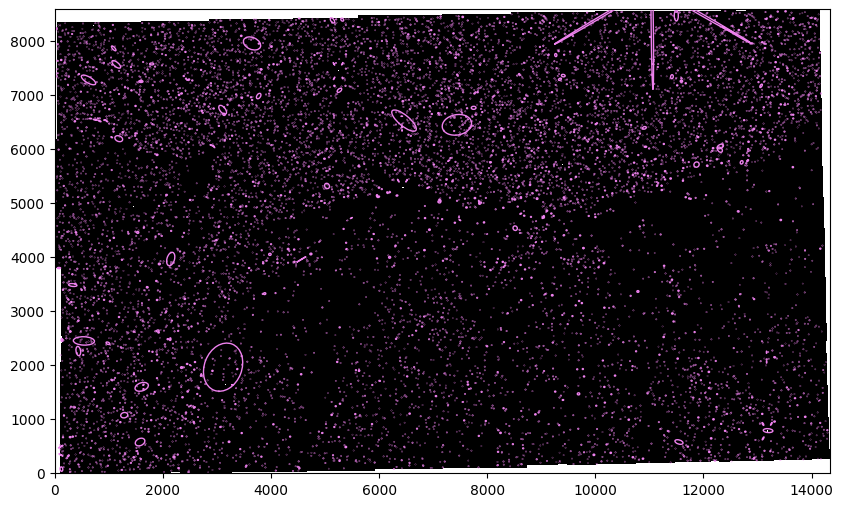

In [38]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('violet')
    ax.add_artist(e)

plt.savefig("nircam_img4.png")

In [16]:
# available fields
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

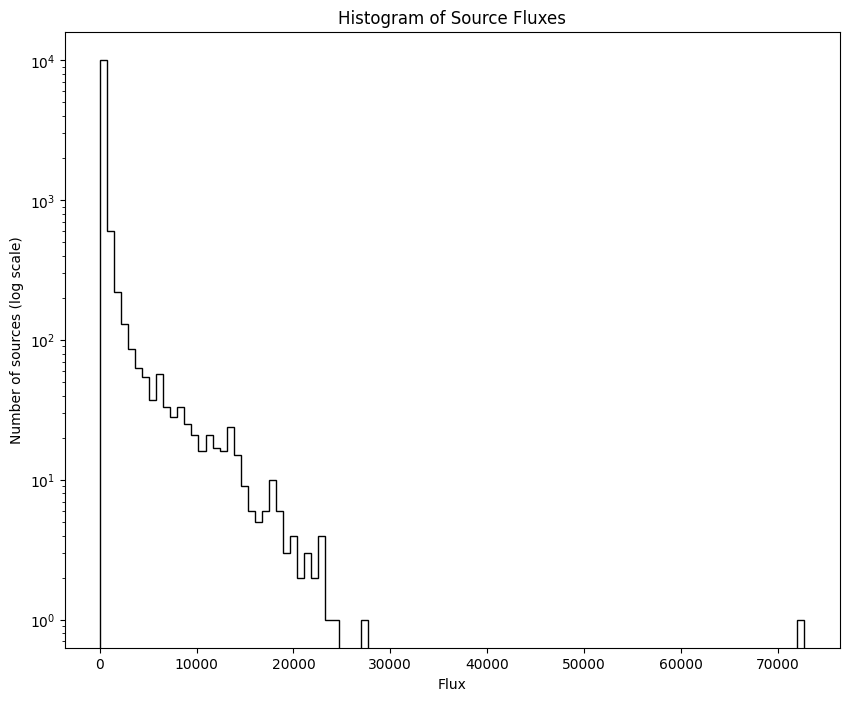

Mean flux: 642.3644786338128
Median flux: 56.75320646286012
Standard deviation: 2226.527562450474
Largest flux value: 72769.94941894533
Coordinates of brightest source: x=13195.355513408475, y=788.9177795112778
Standard deviations from mean: 32.39465172437806


In [18]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

valid = ~np.isnan(flux)
flux = flux[valid]
fluxerr = fluxerr[valid]
objects = objects[valid]

plt.figure()
plt.hist(flux, bins=100, histtype='step', color='black')
plt.yscale('log')
plt.xlabel("Flux")
plt.ylabel("Number of sources (log scale)")
plt.title("Histogram of Source Fluxes")
plt.savefig("nircam_flux_hist_log.png")
plt.show()

mean_flux = np.mean(flux)
median_flux = np.median(flux)
std_flux = np.std(flux)

print(f"Mean flux: {mean_flux}")
print(f"Median flux: {median_flux}")
print(f"Standard deviation: {std_flux}")

max_flux = np.max(flux)
max_index = np.argmax(flux)
print(f"Largest flux value: {max_flux}")

x_pos = objects['x'][max_index]
y_pos = objects['y'][max_index]
print(f"Coordinates of brightest source: x={x_pos}, y={y_pos}")

z_score = (max_flux - mean_flux) / std_flux
print(f"Standard deviations from mean: {z_score}")



In [19]:
# show the first 10 objects results:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 36.514958 +/- 6.052934
object 1: flux = 10.580278 +/- 3.271436
object 2: flux = 249.279545 +/- 15.792458
object 3: flux = 35.355510 +/- 5.956287
object 4: flux = 472.214315 +/- 21.733312
object 5: flux = 13.704591 +/- 3.718461
object 6: flux = 55.563688 +/- 7.462332
object 7: flux = 79.149599 +/- 8.903490
object 8: flux = 19.981370 +/- 4.483757
object 9: flux = 15.242723 +/- 3.919921


In [21]:
# ---------------------------------
# 0. Copy all this script into one cell, between steps 7 and 8 of your final project
#    You will need to install the "reproject" package with pip
#    This script will "reproject" all images onto the same shape using one image as a reference
# ---------------------------------

from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp

# ---------------------------------
# 1. Load your reference image
#    This will define the WCS and shape for all others
# ---------------------------------
file_reference = "jw02731-o001_t017_nircam_clear-f090w_i2d.fits"
with fits.open(file_reference) as hdulist:
    # For JWST i2d images, 'SCI' is commonly the science extension
    ref_header = hdulist['SCI'].header
    ref_data = hdulist['SCI'].data

# Create a WCS object from the reference
ref_wcs = WCS(ref_header)

# This shape will be used for all reprojected images
output_shape = ref_data.shape

# ---------------------------------
# 2. Reproject the other images
# ---------------------------------
fname1 = "jw02731-o001_t017_nircam_clear-f187n_i2d.fits"
fname2 = "jw02731-o001_t017_nircam_clear-f200w_i2d.fits"
fname3 = "jw02731-o001_t017_nircam_clear-f335m_i2d.fits"
fname4 = "jw02731-o001_t017_nircam_clear-f444w_i2d.fits"
fname5 = "jw02731-o001_t017_nircam_f444w-f470n_i2d.fits"

other_filenames = [
    fname1,
    fname2,
    fname3,
    fname4,
    fname5,
]

# Reproject all other files according to the reference
for fname in other_filenames:
    with fits.open(fname) as hdulist:
        data = hdulist['SCI'].data
        header = hdulist['SCI'].header
        wcs_in = WCS(header)
    
    # Reproject this image onto the reference WCS
    # reproject_interp returns (reprojected_data, footprint)
    reprojected_data, footprint = reproject_interp(
        (data, wcs_in),
        ref_wcs,
        shape_out=output_shape
    )

    # Optionally, update the header to match the reference WCS
    # so that the new FITS is self-consistent
    new_header = ref_header.copy()

    # Save the new file
    out_name = fname.replace('.fits', '_reproj.fits')
    hdu = fits.PrimaryHDU(reprojected_data, header=new_header)
    hdu.writeto(out_name, overwrite=True)
    print(f"Reprojected {fname} -> {out_name}")

Reprojected jw02731-o001_t017_nircam_clear-f187n_i2d.fits -> jw02731-o001_t017_nircam_clear-f187n_i2d_reproj.fits
Reprojected jw02731-o001_t017_nircam_clear-f200w_i2d.fits -> jw02731-o001_t017_nircam_clear-f200w_i2d_reproj.fits
Reprojected jw02731-o001_t017_nircam_clear-f335m_i2d.fits -> jw02731-o001_t017_nircam_clear-f335m_i2d_reproj.fits
Reprojected jw02731-o001_t017_nircam_clear-f444w_i2d.fits -> jw02731-o001_t017_nircam_clear-f444w_i2d_reproj.fits


Set DATE-AVG to '2022-06-03T11:43:37.025' from MJD-AVG.
Set DATE-END to '2022-06-03T14:26:16.695' from MJD-END'. [astropy.wcs.wcs]


Reprojected jw02731-o001_t017_nircam_f444w-f470n_i2d.fits -> jw02731-o001_t017_nircam_f444w-f470n_i2d_reproj.fits


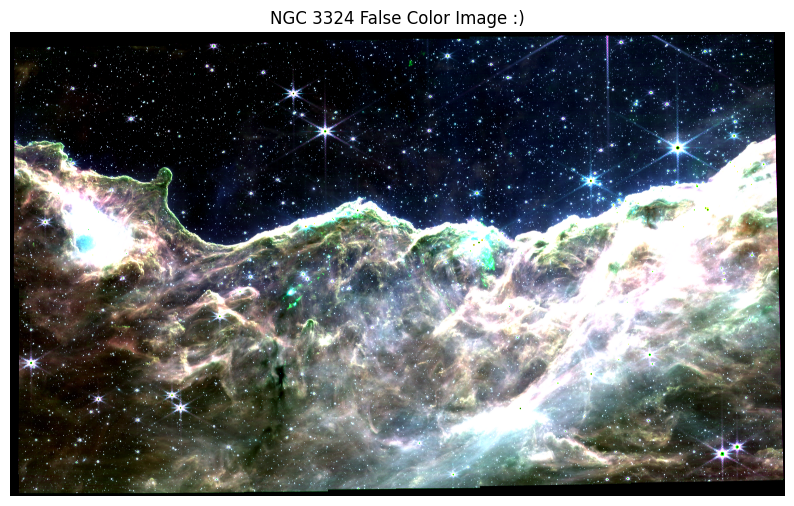

In [39]:
#reprojected files

r_file = "jw02731-o001_t017_nircam_clear-f335m_i2d_reproj.fits"  
g_file = "jw02731-o001_t017_nircam_f444w-f470n_i2d_reproj.fits" 
b_file = "jw02731-o001_t017_nircam_clear-f444w_i2d_reproj.fits"

def load_and_normalize(fname, stretch=0.1):
    with fits.open(fname) as hdul:
        data = hdul[0].data

        # remove nans
        finite_data = data[np.isfinite(data)]
        if finite_data.size == 0:
            raise ValueError(f"{fname} is uhhhh")

        vmin, vmax = np.percentile(finite_data, [stretch * 100, 100 - stretch * 100])

        #now normalizeee
        normed = np.clip((data - vmin) / (vmax - vmin), 0, 1)
        normed = np.nan_to_num(normed) 
        return normed

r = load_and_normalize(r_file)
g = load_and_normalize(g_file)
b = load_and_normalize(b_file)

rgb = np.dstack((r, g, b))

plt.figure(figsize=(10, 10))
plt.imshow(rgb, origin='lower')
plt.title("NGC 3324 False Color Image :)")
plt.axis('off')
plt.savefig("final_combined.png", dpi=300, bbox_inches='tight')
plt.show()
